In [ ]:
# [Cell 1] 한글 폰트 설정
# 그래프에서 한글이 깨지지 않도록 나눔고딕 폰트를 설치하고 등록한다. 노트북 최초 실행 시 한 번만 실행하면 된다.
!apt-get -qq -y install fonts-nanum > /dev/null 2>&1

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

from sklearn.model_selection import (
    StratifiedKFold,
    RepeatedStratifiedKFold
)

In [ ]:
# [Cell 2] 라이브러리 임포트 & Google Drive 마운트
# 분석에 필요한 라이브러리를 불러오고, 데이터가 저장된 Google Drive 경로를 지정한다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from google.colab import drive, userdata

!pip install -q xgboost imbalanced-learn shap openai

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import recall_score, precision_score, roc_auc_score
from imblearn.over_sampling import SMOTE
import shap
from openai import OpenAI

import xgboost as xgb

drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/01Wafer/wafer_data/uci-secom.csv"
SAVE_DIR = "/content/drive/MyDrive/01Wafer/wafer_data/processed"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.makedirs(SAVE_DIR, exist_ok=True)

# [Cell 3] API 키 설정 & 데이터 로드
# Colab Secrets에 저장된 시크릿 "이름"만 넘겨서 API 키를 불러온다 (실제 키 값은 코드에 직접 넣지 않는다).
api_key = userdata.get("open_ai_secom")
client = OpenAI(api_key=api_key)

df = pd.read_csv(DATA_PATH, index_col=0)
print(df.shape)
df.head()

(1567, 591)


,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,Pass/Fail
Time,,,,,,,,,,,,,,,,,,,,,
2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [ ]:
# [Cell 4] Feature/Label 분리 + 기초 전처리
# Pass/Fail 라벨을 분리하고, 결측치 비율이 높은 컬럼과 상수 컬럼을 제거한다.
y = df["Pass/Fail"].map({-1: 0, 1: 1})
X = df.drop(columns=["Pass/Fail"])
X.columns = [f"sensor_{i}" for i in range(X.shape[1])]

print("클래스 분포:\n", y.value_counts())
print(f"불량 비율: {y.mean()*100:.2f}%")

# 결측치 50% 이상 컬럼 제거
missing_ratio = X.isna().mean()
high_missing_cols = missing_ratio[missing_ratio >= 0.5].index.tolist()
X = X.drop(columns=high_missing_cols)
print(f"\n[결측치 50%↑ 제거] {len(high_missing_cols)}개 컬럼 제거")

# 상수 컬럼 제거
nunique = X.nunique(dropna=True)
constant_cols = nunique[nunique <= 1].index.tolist()
X = X.drop(columns=constant_cols)
print(f"[상수 컬럼 제거] {len(constant_cols)}개 컬럼 제거")

print(f"\n최종 X shape: {X.shape}")

클래스 분포:
 Pass/Fail
0    1463
1     104
Name: count, dtype: int64
불량 비율: 6.64%

[결측치 50%↑ 제거] 28개 컬럼 제거
[상수 컬럼 제거] 116개 컬럼 제거

최종 X shape: (1567, 446)


In [ ]:
# [Cell 5] 모델 설정 (XGBoost + Feature Selection)
# 수정: train fold 내부에서 새로 상수가 되는 컬럼까지 한 번 더 걸러내도록 보강
def get_model(model_name, scale_pos_weight=1.0):
    if model_name == "xgboost":
        return xgb.XGBClassifier(
            objective="binary:logistic", eval_metric="auc",
            scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1,
            n_estimators=200, max_depth=5, learning_rate=0.1,
        )
    raise ValueError(f"지원하지 않는 모델: {model_name}")


def select_top_k_features(X_train_imp, y_train, k=100):
    """
    446개 센서 중 통계적으로 유의한 상위 k개만 선택. train fold 내부에서만 fit (leakage 방지).
    [수정] 전체 데이터에서는 상수가 아니었어도 특정 train fold 안에서 분산이 0이 되는
    컬럼이 생길 수 있어, SelectKBest 적용 전에 한 번 더 걸러낸다 (f_classif 0/0 경고 방지).
    """
    variances = X_train_imp.var(axis=0)
    non_constant_mask = variances > 1e-12

    X_filtered = X_train_imp[:, non_constant_mask]
    selector = SelectKBest(score_func=f_classif, k=min(k, X_filtered.shape[1]))
    X_selected = selector.fit_transform(X_filtered, y_train)

    return X_selected, {"mask": non_constant_mask, "selector": selector}


def apply_selector(X_imp, selector_dict):
    """select_top_k_features와 짝을 이루는 적용 함수. test fold / 신규 샘플에 동일하게 사용."""
    if selector_dict is None:
        return X_imp
    X_filtered = X_imp[:, selector_dict["mask"]]
    return selector_dict["selector"].transform(X_filtered)

In [ ]:
# [Cell 6] 증강 함수 정의 (SMOTE / GMM+PCA)
# 수정: GMM+PCA 적용 전 RobustScaler로 스케일링을 추가해 특정 센서의 큰 분산에 PCA가 좌우되지 않도록 함
def smote_oversample(X_train, y_train, target_ratio=0.5, random_state=42):
    n_minority = (y_train == 1).sum()
    k_neighbors = min(5, max(n_minority - 1, 1))
    smote = SMOTE(sampling_strategy=target_ratio, k_neighbors=k_neighbors, random_state=random_state)
    return smote.fit_resample(X_train, y_train)


def select_gmm_k_by_bic(X_minority, max_components=4, random_state=42):
    max_components = min(max_components, max(len(X_minority) - 1, 1))
    bic_scores = [
        GaussianMixture(n_components=k, covariance_type="diag",
                         random_state=random_state, reg_covar=1e-3).fit(X_minority).bic(X_minority)
        for k in range(1, max_components + 1)
    ]
    return int(np.argmin(bic_scores) + 1), bic_scores


def gmm_pca_oversample(X_train, y_train, variance_threshold=0.90, max_components=4,
                        target_ratio=0.5, random_state=42):
    """
    [수정] PCA가 측정 단위/분산이 큰 센서에 좌지우지되는 문제를 막기 위해
    PCA 적용 전 RobustScaler로 스케일을 맞춘다.
    1) 스케일링 -> 2) PCA 차원축소 -> 3) 소수 클래스 PCA 투영
    -> 4) BIC로 GMM 컴포넌트 선택 -> 5) 가상 샘플 생성 후 역스케일까지 역변환
    train fold 내부에서만 fit (leakage 방지).
    """
    pre_scaler = RobustScaler()
    X_train_scaled = pre_scaler.fit_transform(X_train)
    X_minority_scaled = X_train_scaled[y_train == 1]

    pca_full = PCA(random_state=random_state).fit(X_train_scaled)
    n_components_pca = int(np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= variance_threshold) + 1)
    pca = PCA(n_components=n_components_pca, random_state=random_state).fit(X_train_scaled)
    X_minority_pca = pca.transform(X_minority_scaled)

    best_k, _ = select_gmm_k_by_bic(X_minority_pca, max_components, random_state)
    gmm = GaussianMixture(n_components=best_k, covariance_type="diag",
                           random_state=random_state, reg_covar=1e-3).fit(X_minority_pca)

    n_majority = (y_train == 0).sum()
    n_minority = (y_train == 1).sum()
    n_to_generate = max(int(n_majority * target_ratio) - n_minority, 0)
    if n_to_generate == 0:
        return X_train, y_train, {"pca_k": n_components_pca, "gmm_k": best_k, "n_generated": 0}

    X_gen_pca, _ = gmm.sample(n_to_generate)
    X_gen_scaled = pca.inverse_transform(X_gen_pca)
    X_gen = pre_scaler.inverse_transform(X_gen_scaled)  # 원래 단위로 복원

    X_aug = np.vstack([X_train, X_gen])
    y_aug = np.concatenate([y_train, np.ones(n_to_generate)])
    return X_aug, y_aug, {"pca_k": n_components_pca, "gmm_k": best_k, "n_generated": n_to_generate}

In [ ]:
# [Cell 7] Cost-Matrix 기반 최적 Threshold 탐색 함수
# 수정: cost_ratio가 클 때 최적 threshold가 매우 작아지는 경우를 대비해 탐색 범위를 로그스케일로 확장하고,
#       탐색 하한에 값이 몰릴 때 경고 메시지를 보강
def find_cost_optimal_threshold(y_proba, y_true, cost_fn=15, cost_fp=1, thresholds=None):
    """
    FN(불량 놓침) 비용이 FP(헛검사)보다 cost_fn배 크다고 가정.
    [수정] cost_ratio가 커지면(100~500) 최적 threshold가 1e-5보다도 작아질 수 있어
    탐색 범위를 로그스케일로 더 낮은 구간까지 확장.
    """
    if thresholds is None:
        thresholds = np.concatenate([
            np.geomspace(1e-7, 1e-3, 60),
            np.linspace(1e-3, 0.01, 30),
            np.linspace(0.01, 0.99, 99),
        ])
        thresholds = np.unique(thresholds)

    results = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        tn = ((y_pred == 0) & (y_true == 0)).sum()
        fp = ((y_pred == 1) & (y_true == 0)).sum()
        fn = ((y_pred == 0) & (y_true == 1)).sum()
        tp = ((y_pred == 1) & (y_true == 1)).sum()
        total_cost = fn * cost_fn + fp * cost_fp
        results.append({"threshold": t, "fn": fn, "fp": fp, "tp": tp, "tn": tn, "total_cost": total_cost})

    cost_df = pd.DataFrame(results)
    best_row = cost_df.loc[cost_df["total_cost"].idxmin()]

    if best_row["threshold"] <= thresholds.min() * 1.01:
        min_cost = cost_df["total_cost"].min()
        n_tied = (cost_df["total_cost"] == min_cost).sum()
        print(f"⚠️ 경고: 최적 threshold({best_row['threshold']:.2e})가 탐색 범위 하한 근접. "
              f"동일 비용 threshold {n_tied}개 존재 — cost_ratio={cost_fn}에서는 "
              f"거의 모든 샘플을 검사하는 게 최적이라는 의미일 수 있음.")

    return best_row["threshold"], cost_df

In [ ]:
# ============================================================
# [Cell 8] Leakage-free Cost Ratio + Threshold 자동 선택
# (5×5 Repeated Nested CV)
#
# Inner OOF   : Cost Ratio 및 Threshold 선택
# Outer Test  : 선택된 결과의 최종 성능 평가만 수행 (선택 과정에는 관여하지 않음)
# ============================================================

COST_RATIOS = (
    5, 7, 10, 13, 15, 20, 25,
    30, 40, 50, 100, 200, 500
)

COST_FP = 1

# 반드시 결과를 보기 전에 정의하는 운영 조건
MIN_RECALL = 0.65
MIN_INSPECTION_REDUCTION = 55.0

# 모든 Fold에서 동일하게 사용하는 Threshold 탐색 범위
THRESHOLD_GRID = np.unique(
    np.concatenate([
        np.geomspace(1e-7, 1e-3, 80),
        np.geomspace(1e-3, 0.05, 120),
        np.linspace(0.05, 0.99, 95)
    ])
)


# ------------------------------------------------------------
# 1. Strict Inner OOF Probability 생성
#
# Imputer, Feature Selection, SMOTE, 모델 학습을
# 모두 Inner Train 내부에서 수행
# ------------------------------------------------------------
def get_strict_inner_oof_proba(
    X_train_raw,
    y_train,
    augmentation="smote",
    model_name="xgboost",
    inner_splits=5,
    random_state=42,
    use_feature_selection=True
):
    X_train_raw = np.asarray(X_train_raw)
    y_train = np.asarray(y_train)

    inner_cv = StratifiedKFold(
        n_splits=inner_splits,
        shuffle=True,
        random_state=random_state
    )

    oof_proba = np.full(
        len(y_train),
        np.nan,
        dtype=float
    )

    for inner_fold, (
        inner_train_idx,
        inner_val_idx
    ) in enumerate(
        inner_cv.split(X_train_raw, y_train),
        start=1
    ):
        X_inner_train = X_train_raw[inner_train_idx]
        X_inner_val = X_train_raw[inner_val_idx]

        y_inner_train = y_train[inner_train_idx]

        # Imputation도 Inner Train에서만 fit
        imputer = SimpleImputer(strategy="median")

        X_inner_train_imp = imputer.fit_transform(
            X_inner_train
        )
        X_inner_val_imp = imputer.transform(
            X_inner_val
        )

        # Feature Selection도 Inner Train에서만 fit
        if use_feature_selection:
            (
                X_inner_train_selected,
                selector
            ) = select_top_k_features(
                X_inner_train_imp,
                y_inner_train,
                k=100
            )

            X_inner_val_selected = apply_selector(
                X_inner_val_imp,
                selector
            )
        else:
            X_inner_train_selected = (
                X_inner_train_imp
            )
            X_inner_val_selected = X_inner_val_imp

        # 증강은 Inner Train에만 적용
        if augmentation == "smote":
            X_fit, y_fit = smote_oversample(
                X_inner_train_selected,
                y_inner_train,
                random_state=(
                    random_state + inner_fold
                )
            )

        elif augmentation == "gmm_pca":
            X_fit, y_fit, _ = gmm_pca_oversample(
                X_inner_train_selected,
                y_inner_train,
                random_state=(
                    random_state + inner_fold
                )
            )

        else:
            X_fit = X_inner_train_selected
            y_fit = y_inner_train

        scale_pos_weight = (
            (y_fit == 0).sum()
            / max((y_fit == 1).sum(), 1)
        )

        pipeline = Pipeline([
            ("scaler", RobustScaler()),
            (
                "model",
                get_model(
                    model_name,
                    scale_pos_weight
                )
            )
        ])

        pipeline.fit(X_fit, y_fit)

        # Inner Validation에는 증강하지 않음
        oof_proba[inner_val_idx] = (
            pipeline.predict_proba(
                X_inner_val_selected
            )[:, 1]
        )

    if np.isnan(oof_proba).any():
        raise RuntimeError(
            "Inner OOF probability에 "
            "미할당 값이 존재합니다."
        )

    return oof_proba


# ------------------------------------------------------------
# 2. Inner OOF에서 Cost Ratio와 Threshold 동시 선택
# ------------------------------------------------------------
def select_ratio_and_threshold_from_oof(
    y_true,
    y_proba,
    cost_ratios=COST_RATIOS,
    cost_fp=COST_FP,
    min_recall=MIN_RECALL,
    min_inspection_reduction=
        MIN_INSPECTION_REDUCTION,
    thresholds=THRESHOLD_GRID
):
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    ratio_results = []

    for ratio in cost_ratios:
        best_threshold, cost_df = (
            find_cost_optimal_threshold(
                y_proba=y_proba,
                y_true=y_true,
                cost_fn=ratio,
                cost_fp=cost_fp,
                thresholds=thresholds
            )
        )

        y_pred = (
            y_proba >= best_threshold
        ).astype(int)

        ratio_results.append({
            "cost_ratio": int(ratio),
            "best_threshold":
                float(best_threshold),
            "recall": recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "precision": precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "inspection_reduction_pct":
                (1 - y_pred.mean()) * 100,
            "total_cost":
                float(cost_df["total_cost"].min())
        })

    ratio_df = pd.DataFrame(ratio_results)

    # 사전 정의한 운영조건을 만족하는 후보
    feasible = ratio_df[
        (ratio_df["recall"] >= min_recall)
        &
        (
            ratio_df["inspection_reduction_pct"]
            >= min_inspection_reduction
        )
    ].copy()

    if not feasible.empty:
        # 운영조건을 만족하는 가장 작은 Cost Ratio
        selected = (
            feasible
            .sort_values(
                [
                    "cost_ratio",
                    "recall"
                ],
                ascending=[True, False]
            )
            .iloc[0]
            .copy()
        )

        selection_reason = (
            "운영조건을 만족하는 최소 Cost Ratio"
        )

    else:
        # 후보가 없으면 목표 미달 정도가 가장 작은 값
        ratio_df["constraint_gap"] = (
            np.maximum(
                min_recall - ratio_df["recall"],
                0
            ) / min_recall
            +
            np.maximum(
                min_inspection_reduction
                - ratio_df[
                    "inspection_reduction_pct"
                ],
                0
            ) / min_inspection_reduction
        )

        selected = (
            ratio_df
            .sort_values(
                [
                    "constraint_gap",
                    "cost_ratio"
                ]
            )
            .iloc[0]
            .copy()
        )

        selection_reason = (
            "운영조건과 가장 가까운 Cost Ratio"
        )

    selected["selection_reason"] = (
        selection_reason
    )

    return selected, ratio_df


# ------------------------------------------------------------
# 3. Outer Train 전체로 최종 모델 학습
# ------------------------------------------------------------
def fit_outer_train_model(
    X_outer_train,
    y_outer_train,
    augmentation="smote",
    model_name="xgboost",
    random_state=42,
    use_feature_selection=True
):
    imputer = SimpleImputer(strategy="median")

    X_train_imp = imputer.fit_transform(
        X_outer_train
    )

    if use_feature_selection:
        (
            X_train_selected,
            selector
        ) = select_top_k_features(
            X_train_imp,
            y_outer_train,
            k=100
        )
    else:
        X_train_selected = X_train_imp
        selector = None

    if augmentation == "smote":
        X_fit, y_fit = smote_oversample(
            X_train_selected,
            y_outer_train,
            random_state=random_state
        )

    elif augmentation == "gmm_pca":
        X_fit, y_fit, _ = gmm_pca_oversample(
            X_train_selected,
            y_outer_train,
            random_state=random_state
        )

    else:
        X_fit = X_train_selected
        y_fit = y_outer_train

    scale_pos_weight = (
        (y_fit == 0).sum()
        / max((y_fit == 1).sum(), 1)
    )

    pipeline = Pipeline([
        ("scaler", RobustScaler()),
        (
            "model",
            get_model(
                model_name,
                scale_pos_weight
            )
        )
    ])

    pipeline.fit(X_fit, y_fit)

    return pipeline, imputer, selector


# ------------------------------------------------------------
# 4. 5×5 Repeated Nested CV
# ------------------------------------------------------------
def run_repeated_nested_auto_selection(
    X,
    y,
    model_name="xgboost",
    augmentation="smote",
    outer_splits=5,
    outer_repeats=5,
    inner_splits=5,
    random_state=42,
    use_feature_selection=True
):
    X_array = np.asarray(X)
    y_array = np.asarray(y)

    outer_cv = RepeatedStratifiedKFold(
        n_splits=outer_splits,
        n_repeats=outer_repeats,
        random_state=random_state
    )

    outer_results = []
    fold_artifacts = []
    inner_sensitivity_results = []

    for outer_id, (
        train_idx,
        test_idx
    ) in enumerate(
        outer_cv.split(X_array, y_array),
        start=1
    ):
        repeat_id = (
            (outer_id - 1) // outer_splits
        ) + 1

        fold_in_repeat = (
            (outer_id - 1) % outer_splits
        ) + 1

        X_outer_train = X_array[train_idx]
        X_outer_test = X_array[test_idx]

        y_outer_train = y_array[train_idx]
        y_outer_test = y_array[test_idx]

        # ----------------------------------------------
        # Inner OOF에서 Ratio와 Threshold 선택
        # ----------------------------------------------
        inner_oof_proba = (
            get_strict_inner_oof_proba(
                X_train_raw=X_outer_train,
                y_train=y_outer_train,
                augmentation=augmentation,
                model_name=model_name,
                inner_splits=inner_splits,
                random_state=(
                    random_state + outer_id
                ),
                use_feature_selection=
                    use_feature_selection
            )
        )

        selected, inner_ratio_df = (
            select_ratio_and_threshold_from_oof(
                y_true=y_outer_train,
                y_proba=inner_oof_proba,
                cost_ratios=COST_RATIOS,
                cost_fp=COST_FP,
                min_recall=MIN_RECALL,
                min_inspection_reduction=
                    MIN_INSPECTION_REDUCTION,
                thresholds=THRESHOLD_GRID
            )
        )

        selected_ratio = int(
            selected["cost_ratio"]
        )
        selected_threshold = float(
            selected["best_threshold"]
        )

        # Fold별 Inner 민감도 결과 저장
        inner_ratio_df = inner_ratio_df.copy()
        inner_ratio_df["outer_id"] = outer_id
        inner_ratio_df["repeat"] = repeat_id
        inner_ratio_df[
            "fold_in_repeat"
        ] = fold_in_repeat

        inner_sensitivity_results.append(
            inner_ratio_df
        )

        # ----------------------------------------------
        # Outer Train 전체로 최종 모델 학습
        # ----------------------------------------------
        (
            pipeline,
            imputer,
            selector
        ) = fit_outer_train_model(
            X_outer_train=X_outer_train,
            y_outer_train=y_outer_train,
            augmentation=augmentation,
            model_name=model_name,
            random_state=(
                random_state + outer_id
            ),
            use_feature_selection=
                use_feature_selection
        )

        # Outer Test에는 transform만 적용
        X_outer_test_imp = imputer.transform(
            X_outer_test
        )

        X_outer_test_selected = apply_selector(
            X_outer_test_imp,
            selector
        )

        outer_test_proba = (
            pipeline.predict_proba(
                X_outer_test_selected
            )[:, 1]
        )

        outer_test_pred = (
            outer_test_proba
            >= selected_threshold
        ).astype(int)

        outer_result = {
            "fold": outer_id,
            "repeat": repeat_id,
            "fold_in_repeat": fold_in_repeat,
            "selected_cost_ratio":
                selected_ratio,
            "best_threshold":
                selected_threshold,
            "inner_recall":
                float(selected["recall"]),
            "inner_inspection_reduction_pct":
                float(
                    selected[
                        "inspection_reduction_pct"
                    ]
                ),
            "n_total": len(y_outer_test),
            "n_flagged":
                int(outer_test_pred.sum()),
            "inspection_reduction_pct":
                (
                    1 - outer_test_pred.mean()
                ) * 100,
            "recall": recall_score(
                y_outer_test,
                outer_test_pred,
                zero_division=0
            ),
            "precision": precision_score(
                y_outer_test,
                outer_test_pred,
                zero_division=0
            ),
            "auc": roc_auc_score(
                y_outer_test,
                outer_test_proba
            )
        }

        outer_results.append(outer_result)

        fold_artifacts.append({
            "fold": outer_id,
            "repeat": repeat_id,
            "fold_in_repeat": fold_in_repeat,
            "pipeline": pipeline,
            "imputer": imputer,
            "selector": selector,
            "train_idx": train_idx,
            "test_idx": test_idx,
            "best_threshold":
                selected_threshold,
            "selected_cost_ratio":
                selected_ratio,
            "inner_oof_proba":
                inner_oof_proba,
            "inner_ratio_df":
                inner_ratio_df
        })

        print(
            f"[Repeat {repeat_id} / "
            f"Fold {fold_in_repeat}] "
            f"Ratio={selected_ratio}:1 | "
            f"Threshold={selected_threshold:.5f} | "
            f"Outer Recall="
            f"{outer_result['recall']:.3f} | "
            f"검사량 감소="
            f"{outer_result['inspection_reduction_pct']:.1f}%"
        )

    vm_results = pd.DataFrame(
        outer_results
    )

    inner_sensitivity_long = pd.concat(
        inner_sensitivity_results,
        ignore_index=True
    )

    return (
        vm_results,
        fold_artifacts,
        inner_sensitivity_long
    )


vm_results, fold_artifacts, inner_sensitivity_long = (
    run_repeated_nested_auto_selection(
        X=X.values,
        y=y.values,
        model_name="xgboost",
        augmentation="smote",
        outer_splits=5,
        outer_repeats=5,
        inner_splits=5,
        random_state=42,
        use_feature_selection=True
    )
)


print("\n" + "=" * 70)
print("Outer Test 평균: 5×5 Repeated Nested CV")
print("=" * 70)

print(
    vm_results[
        [
            "recall",
            "precision",
            "auc",
            "inspection_reduction_pct"
        ]
    ].mean()
)

print("\n=== Fold별 자동 선정 Cost Ratio 분포 ===")

selected_ratio_distribution = (
    vm_results["selected_cost_ratio"]
    .value_counts()
    .sort_index()
)

print(selected_ratio_distribution)

print("\n=== Fold별 Threshold 요약 ===")

print(
    vm_results["best_threshold"]
    .describe()
)

[Repeat 1 / Fold 1] Ratio=15:1 | Threshold=0.00847 | Outer Recall=0.524 | 검사량 감소=56.4%
[Repeat 1 / Fold 2] Ratio=13:1 | Threshold=0.00590 | Outer Recall=0.810 | 검사량 감소=56.7%
[Repeat 1 / Fold 3] Ratio=13:1 | Threshold=0.02127 | Outer Recall=0.700 | 검사량 감소=71.2%
[Repeat 1 / Fold 4] Ratio=13:1 | Threshold=0.00439 | Outer Recall=0.810 | 검사량 감소=51.8%
[Repeat 1 / Fold 5] Ratio=13:1 | Threshold=0.00743 | Outer Recall=0.619 | 검사량 감소=62.3%
[Repeat 2 / Fold 1] Ratio=13:1 | Threshold=0.00485 | Outer Recall=0.714 | 검사량 감소=52.5%
[Repeat 2 / Fold 2] Ratio=10:1 | Threshold=0.01216 | Outer Recall=0.524 | 검사량 감소=67.8%
[Repeat 2 / Fold 3] Ratio=20:1 | Threshold=0.00372 | Outer Recall=0.850 | 검사량 감소=49.5%
[Repeat 2 / Fold 4] Ratio=10:1 | Threshold=0.01805 | Outer Recall=0.762 | 검사량 감소=69.3%
[Repeat 2 / Fold 5] Ratio=15:1 | Threshold=0.00999 | Outer Recall=0.714 | 검사량 감소=62.3%
[Repeat 3 / Fold 1] Ratio=13:1 | Threshold=0.00793 | Outer Recall=0.381 | 검사량 감소=61.5%
[Repeat 3 / Fold 2] Ratio=10:1 | Threshold=


Strict OOF 기반 배포 Operating Point
자동 선정 Cost Ratio : 13:1
자동 선정 Threshold  : 0.00571
OOF Recall           : 0.760
OOF Precision        : 0.114
OOF 검사량 감소      : 55.8%
선정 기준            : 운영조건을 만족하는 최소 Cost Ratio


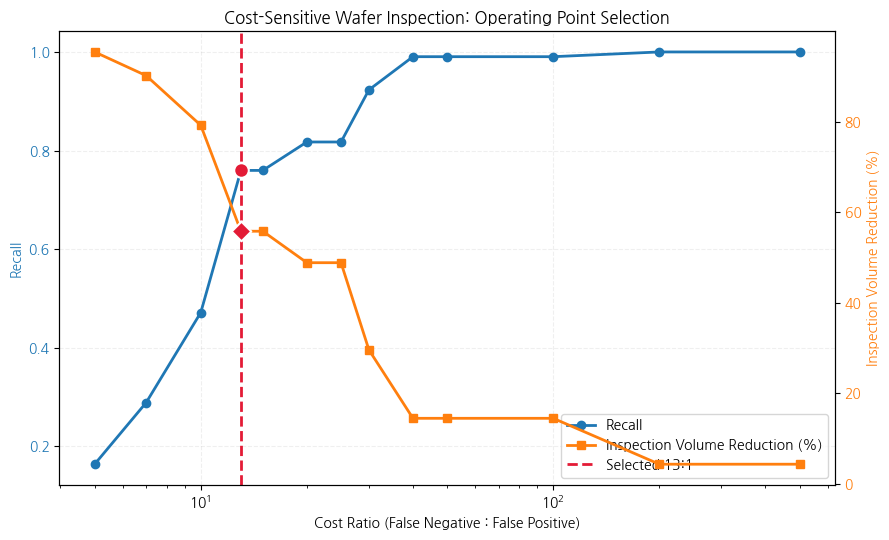

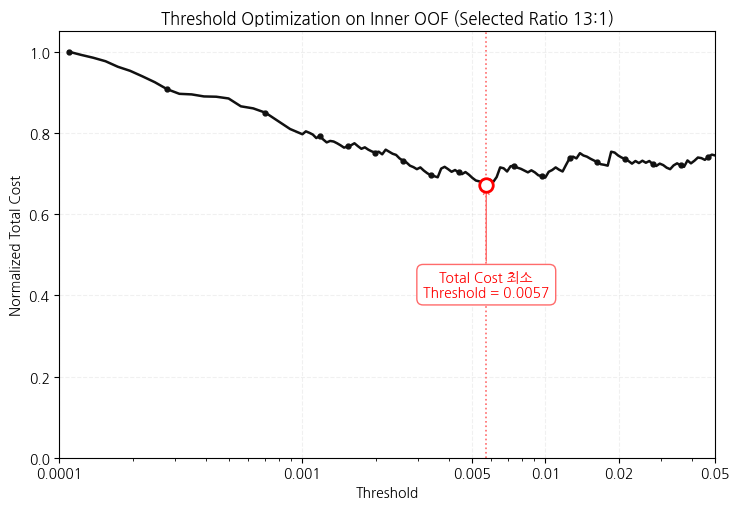


장표 입력용 결과
배포 Operating Point : 13:1
대표 OOF Threshold   : 0.00571
Outer Test Recall    : 68.7%
Outer Test Precision : 11.7%
Outer Test AUC       : 0.719
검사 대상 감소       : 60.1%

Fold별 Cost Ratio 선택 분포:
selected_cost_ratio
7      1
10     7
13    12
15     3
20     2
Name: count, dtype: int64


In [ ]:
# ============================================================
# [Cell 9] 전체 데이터 Strict OOF 기반 배포 Operating Point 선정 + 시각화
#
# 주의: 최종 성능(Outer Test 평균)은 [Cell 8]에서 이미 확정되었으며,
#       이 셀은 배포용 Ratio/Threshold를 정하기 위한 것으로 Outer Test 결과를 선택에 사용하지 않음
# ============================================================


# ------------------------------------------------------------
# 1. 전체 데이터 Strict OOF Probability
# ------------------------------------------------------------
full_oof_proba = get_strict_inner_oof_proba(
    X_train_raw=X.values,
    y_train=y.values,
    augmentation="smote",
    model_name="xgboost",
    inner_splits=5,
    random_state=2026,
    use_feature_selection=True
)


# ------------------------------------------------------------
# 2. 전체 데이터 OOF에서 배포용 Ratio와 Threshold 선정
# ------------------------------------------------------------
deployment_selected, sensitivity_df = (
    select_ratio_and_threshold_from_oof(
        y_true=y.values,
        y_proba=full_oof_proba,
        cost_ratios=COST_RATIOS,
        cost_fp=COST_FP,
        min_recall=MIN_RECALL,
        min_inspection_reduction=
            MIN_INSPECTION_REDUCTION,
        thresholds=THRESHOLD_GRID
    )
)

selected_cost_ratio = int(
    deployment_selected["cost_ratio"]
)

selected_threshold = float(
    deployment_selected["best_threshold"]
)


print("\n" + "=" * 70)
print("Strict OOF 기반 배포 Operating Point")
print("=" * 70)

print(
    f"자동 선정 Cost Ratio : "
    f"{selected_cost_ratio}:1"
)

print(
    f"자동 선정 Threshold  : "
    f"{selected_threshold:.5f}"
)

print(
    f"OOF Recall           : "
    f"{deployment_selected['recall']:.3f}"
)

print(
    f"OOF Precision        : "
    f"{deployment_selected['precision']:.3f}"
)

print(
    f"OOF 검사량 감소      : "
    f"{deployment_selected['inspection_reduction_pct']:.1f}%"
)

print(
    f"선정 기준            : "
    f"{deployment_selected['selection_reason']}"
)


# ------------------------------------------------------------
# 3. Cost Ratio 민감도 그래프
# ------------------------------------------------------------
fig, ax1 = plt.subplots(
    figsize=(9, 5.5)
)

recall_line, = ax1.plot(
    sensitivity_df["cost_ratio"],
    sensitivity_df["recall"],
    marker="o",
    linewidth=2,
    color="tab:blue",
    label="Recall"
)

ax1.set_xscale("log")

ax1.set_xlabel(
    "Cost Ratio "
    "(False Negative : False Positive)"
)

ax1.set_ylabel(
    "Recall",
    color="tab:blue"
)

ax1.tick_params(
    axis="y",
    labelcolor="tab:blue"
)

ax1.grid(
    alpha=0.2,
    linestyle="--"
)

ax2 = ax1.twinx()

reduction_line, = ax2.plot(
    sensitivity_df["cost_ratio"],
    sensitivity_df[
        "inspection_reduction_pct"
    ],
    marker="s",
    linewidth=2,
    color="tab:orange",
    label="Inspection Volume Reduction (%)"
)

ax2.set_ylabel(
    "Inspection Volume Reduction (%)",
    color="tab:orange"
)

ax2.tick_params(
    axis="y",
    labelcolor="tab:orange"
)

selected_line = ax1.axvline(
    selected_cost_ratio,
    color="#E31B36",
    linestyle="--",
    linewidth=2,
    label=(
        f"Selected "
        f"{selected_cost_ratio}:1"
    )
)

ax1.scatter(
    selected_cost_ratio,
    deployment_selected["recall"],
    color="#E31B36",
    edgecolor="white",
    linewidth=1.5,
    s=110,
    zorder=10
)

ax2.scatter(
    selected_cost_ratio,
    deployment_selected[
        "inspection_reduction_pct"
    ],
    marker="D",
    color="#E31B36",
    edgecolor="white",
    linewidth=1.5,
    s=100,
    zorder=10
)

ax1.legend(
    handles=[
        recall_line,
        reduction_line,
        selected_line
    ],
    loc="best"
)

plt.title(
    "Cost-Sensitive Wafer Inspection: "
    "Operating Point Selection"
)

fig.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. 선택된 Cost Ratio에서 Total Cost Curve
# ------------------------------------------------------------
_, total_cost_df = find_cost_optimal_threshold(
    y_proba=full_oof_proba,
    y_true=y.values,
    cost_fn=selected_cost_ratio,
    cost_fp=COST_FP,
    thresholds=THRESHOLD_GRID
)

# 장표용 Threshold 구간
plot_cost_df = total_cost_df[
    (
        total_cost_df["threshold"]
        >= 1e-4
    )
    &
    (
        total_cost_df["threshold"]
        <= 0.05
    )
].copy()

# 자동 선정 Threshold가 반드시 포함되게 처리
selected_cost_row = total_cost_df.iloc[
    (
        total_cost_df["threshold"]
        - selected_threshold
    ).abs().argsort()[:1]
].copy()

plot_cost_df = (
    pd.concat([
        plot_cost_df,
        selected_cost_row
    ])
    .drop_duplicates("threshold")
    .sort_values("threshold")
)

# 그림 표시용 정규화
plot_cost_df["normalized_total_cost"] = (
    plot_cost_df["total_cost"]
    / plot_cost_df["total_cost"].max()
)

selected_plot_row = plot_cost_df.iloc[
    (
        plot_cost_df["threshold"]
        - selected_threshold
    ).abs().argsort()[:1]
].iloc[0]

selected_normalized_cost = float(
    selected_plot_row[
        "normalized_total_cost"
    ]
)


# ------------------------------------------------------------
# 5. Threshold–Total Cost Curve
# ------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(7.5, 5.2)
)

ax.plot(
    plot_cost_df["threshold"],
    plot_cost_df[
        "normalized_total_cost"
    ],
    color="#111111",
    linewidth=1.8,
    marker="o",
    markersize=3.5,
    markevery=8
)

ax.set_xscale("log")
ax.set_xlim(1e-4, 0.05)
ax.set_ylim(0, 1.05)

threshold_ticks = [
    0.0001,
    0.001,
    0.005,
    0.01,
    0.02,
    0.05
]

ax.set_xticks(threshold_ticks)

ax.set_xticklabels([
    "0.0001",
    "0.001",
    "0.005",
    "0.01",
    "0.02",
    "0.05"
])

ax.axvline(
    selected_threshold,
    color="#FF6B6B",
    linestyle=":",
    linewidth=1.2
)

ax.scatter(
    selected_threshold,
    selected_normalized_cost,
    s=95,
    facecolor="white",
    edgecolor="red",
    linewidth=2,
    zorder=10
)

ax.annotate(
    (
        "Total Cost 최소\n"
        f"Threshold = "
        f"{selected_threshold:.4f}"
    ),
    xy=(
        selected_threshold,
        selected_normalized_cost
    ),
    xytext=(0, -62),
    textcoords="offset points",
    ha="center",
    va="top",
    color="red",
    fontsize=10,
    fontweight="bold",
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": "white",
        "edgecolor": "#FF6B6B"
    },
    arrowprops={
        "arrowstyle": "->",
        "color": "#FF6B6B"
    }
)

ax.set_xlabel("Threshold")
ax.set_ylabel("Normalized Total Cost")

ax.set_title(
    "Threshold Optimization on Inner OOF "
    f"(Selected Ratio {selected_cost_ratio}:1)"
)

ax.grid(
    alpha=0.18,
    linestyle="--"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. 장표에 사용할 최종 결과 확인
# ------------------------------------------------------------
outer_summary = vm_results[
    [
        "recall",
        "precision",
        "auc",
        "inspection_reduction_pct"
    ]
].mean()

print("\n" + "=" * 70)
print("장표 입력용 결과")
print("=" * 70)

print(
    f"배포 Operating Point : "
    f"{selected_cost_ratio}:1"
)

print(
    f"대표 OOF Threshold   : "
    f"{selected_threshold:.5f}"
)

print(
    f"Outer Test Recall    : "
    f"{outer_summary['recall']:.1%}"
)

print(
    f"Outer Test Precision : "
    f"{outer_summary['precision']:.1%}"
)

print(
    f"Outer Test AUC       : "
    f"{outer_summary['auc']:.3f}"
)

print(
    f"검사 대상 감소       : "
    f"{outer_summary['inspection_reduction_pct']:.1f}%"
)

print("\nFold별 Cost Ratio 선택 분포:")

print(
    vm_results[
        "selected_cost_ratio"
    ]
    .value_counts()
    .sort_index()
)

=== SMOTE Global SHAP Top 10 ===
    sensor  mean_abs_shap  selected_folds  selection_rate_pct
 sensor_59       0.605282              25               100.0
sensor_247       0.430055              24                96.0
 sensor_21       0.358193              25               100.0
 sensor_33       0.338661              22                88.0
 sensor_95       0.296928              19                76.0
sensor_460       0.281499              21                84.0
sensor_121       0.278607              25               100.0
sensor_130       0.272001              25               100.0
sensor_129       0.223390              25               100.0
sensor_511       0.205715              17                68.0


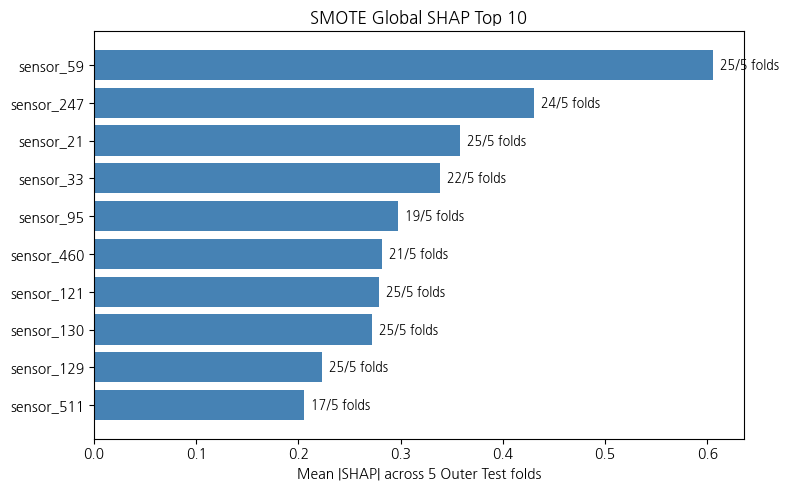

In [ ]:
# [Cell 10] SMOTE 모델 Global SHAP
# 5개 Outer Test fold 각각에서 센서별 평균 |SHAP|을 계산한 뒤 fold 간 결과를 통합한다.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

global_shap_fold_results = []

for art in fold_artifacts:
    fold_id = art["fold"]

    # 1. 해당 Fold의 Outer Test 데이터
    X_test = X.values[art["test_idx"]]

    # 2. Outer Train에서 학습된 전처리기만 적용
    X_test_imp = art["imputer"].transform(X_test)
    X_test_selected = apply_selector(
        X_test_imp,
        art["selector"]
    )

    # 3. Fold별 선택 Feature 이름 복원
    constant_mask = art["selector"]["mask"]
    selected_mask = (
        art["selector"]["selector"]
        .get_support(indices=True)
    )

    feature_names_after_constant = np.asarray(
        X.columns
    )[constant_mask]

    selected_feature_names = (
        feature_names_after_constant[selected_mask]
        .tolist()
    )

    # 4. 모델이 학습할 때 사용한 스케일로 변환
    scaler = art["pipeline"].named_steps["scaler"]
    model = art["pipeline"].named_steps["model"]

    X_test_scaled = scaler.transform(X_test_selected)

    # 5. Outer Test 기준 SHAP 계산
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_scaled)

    if isinstance(shap_values, list):
        shap_values = shap_values[-1]

    shap_values = np.asarray(shap_values)

    # 6. 해당 Fold에서 센서별 평균 절대 SHAP
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    fold_df = pd.DataFrame({
        "fold": fold_id,
        "sensor": selected_feature_names,
        "mean_abs_shap": mean_abs_shap
    })

    global_shap_fold_results.append(fold_df)


# Fold 결과 결합
global_shap_fold_df = pd.concat(
    global_shap_fold_results,
    ignore_index=True
)

# 센서가 선택되지 않은 Fold는 중요도 0으로 처리
shap_pivot = global_shap_fold_df.pivot_table(
    index="sensor",
    columns="fold",
    values="mean_abs_shap",
    aggfunc="mean"
).fillna(0)

# 5-Fold Global SHAP 요약
global_shap_summary = pd.DataFrame({
    "mean_abs_shap": shap_pivot.mean(axis=1),
    "selected_folds": (shap_pivot > 0).sum(axis=1)
}).reset_index()

global_shap_summary["selection_rate_pct"] = (
    global_shap_summary["selected_folds"]
    / len(fold_artifacts)
    * 100
)

global_shap_summary = global_shap_summary.sort_values(
    "mean_abs_shap",
    ascending=False
).reset_index(drop=True)

global_shap_top10 = global_shap_summary.head(10)

print("=== SMOTE Global SHAP Top 10 ===")
print(global_shap_top10.to_string(index=False))

# 결과 저장
global_shap_summary.to_csv(
    f"{SAVE_DIR}/smote_global_shap_summary.csv",
    index=False
)

# 시각화
plot_df = global_shap_top10.sort_values(
    "mean_abs_shap",
    ascending=True
)

plt.figure(figsize=(8, 5))
plt.barh(
    plot_df["sensor"],
    plot_df["mean_abs_shap"],
    color="steelblue"
)
plt.xlabel("Mean |SHAP| across 5 Outer Test folds")
plt.title("SMOTE Global SHAP Top 10")

for i, (_, row) in enumerate(plot_df.iterrows()):
    plt.text(
        row["mean_abs_shap"],
        i,
        f"  {int(row['selected_folds'])}/5 folds",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [ ]:
# [Cell 11] Model-level LLM Summary
# 모델 성능·Global SHAP 결과를 LLM으로 요약해 현장에서 읽을 수 있는 문장으로 정리한다.

smote_metrics = vm_results[
    ["recall", "precision", "auc", "inspection_reduction_pct"]
].mean()

top5 = global_shap_summary.head(5)

top5_text = "\n".join([
    f"- {row.sensor}: 평균 |SHAP| {row.mean_abs_shap:.4f}, "
    f"선택 빈도 {int(row.selected_folds)}/5 folds"
    for _, row in top5.iterrows()
])

model_context = f"""
[검증 구조]
- SMOTE XGBoost
- 5-Fold Outer Test
- Cost Ratio FN:FP = 15:1

[평균 성능]
- Recall: {smote_metrics['recall']:.1%}
- Precision: {smote_metrics['precision']:.1%}
- AUC: {smote_metrics['auc']:.3f}
- 검사 대상 감소: {smote_metrics['inspection_reduction_pct']:.1f}%

[Global SHAP Top 5]
{top5_text}
"""

model_summary_prompt = f"""
당신은 반도체 공정 데이터 분석 결과를 요약하는 어시스턴트입니다.

아래 결과만 사용하여 모델 전체 요약을 작성하세요.
익명 센서의 물리적 의미나 인과관계를 추정하지 마세요.

{model_context}

다음 형식으로 작성하세요.

1. 모델 검증 결과
2. 모델이 전반적으로 중요하게 활용한 센서
3. 운영상 Trade-off
4. 현장 적용 전 확인 사항
"""

model_summary_response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "user", "content": model_summary_prompt}
    ],
    temperature=0.2
)

model_level_report = (
    model_summary_response
    .choices[0]
    .message
    .content
)

print(model_level_report)

1. **모델 검증 결과**  
   - 사용된 검증 구조는 SMOTE XGBoost를 기반으로 하였으며, 5-Fold Outer Test를 통해 평가되었습니다.  
   - 비용 비율(FN:FP)은 15:1로 설정되었습니다.  
   - 평균 성능 지표는 다음과 같습니다:  
     - Recall: 68.7%  
     - Precision: 11.7%  
     - AUC: 0.719  
     - 검사 대상 감소: 60.1%  

2. **모델이 전반적으로 중요하게 활용한 센서**  
   - 모델에서 가장 중요하게 활용된 센서는 다음과 같습니다:  
     - sensor_59: 평균 |SHAP| 0.6053, 선택 빈도 25/5 folds  
     - sensor_247: 평균 |SHAP| 0.4301, 선택 빈도 24/5 folds  
     - sensor_21: 평균 |SHAP| 0.3582, 선택 빈도 25/5 folds  
     - sensor_33: 평균 |SHAP| 0.3387, 선택 빈도 22/5 folds  
     - sensor_95: 평균 |SHAP| 0.2969, 선택 빈도 19/5 folds  

3. **운영상 Trade-off**  
   - 모델의 Recall이 68.7%로 상대적으로 높은 반면, Precision은 11.7%로 낮아 False Positive가 많을 가능성이 있습니다. 이는 실제 양성 사례를 놓치지 않기 위해 더 많은 검사 대상을 포함해야 할 수 있음을 의미합니다. 따라서, 운영 시 False Negative를 줄이는 데 중점을 두어야 하며, 이로 인해 False Positive가 증가할 수 있는 Trade-off가 존재합니다.

4. **현장 적용 전 확인 사항**  
   - 모델의 Recall과 Precision 간의 불균형을 고려하여, 현장 적용 전에 추가적인 검증이 필요합니다.  
   - 중요 센서의 신뢰성을 확인하고, 각 센서의 데이터 품질을 점검해야 합니다.  
   

In [ ]:
# [Cell 12] Feature Importance 비교 검증 (스케일링 전 / 스케일링 후 / 기준선 3종 비교)

def gmm_pca_oversample_no_scaling(X_train, y_train, variance_threshold=0.90,
                                    max_components=4, target_ratio=0.5, random_state=42):
    """비교용으로 재현한 '버그 있던' 버전 (스케일링 없이 PCA)."""
    X_minority = X_train[y_train == 1]
    pca_full = PCA(random_state=random_state).fit(X_train)
    n_components_pca = int(np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= variance_threshold) + 1)
    pca = PCA(n_components=n_components_pca, random_state=random_state).fit(X_train)
    X_minority_pca = pca.transform(X_minority)

    best_k, _ = select_gmm_k_by_bic(X_minority_pca, max_components, random_state)
    gmm = GaussianMixture(n_components=best_k, covariance_type="diag",
                           random_state=random_state, reg_covar=1e-3).fit(X_minority_pca)

    n_majority = (y_train == 0).sum()
    n_to_generate = max(int(n_majority * target_ratio) - len(X_minority), 0)
    if n_to_generate == 0:
        return X_train, y_train
    X_gen_pca, _ = gmm.sample(n_to_generate)
    X_gen = pca.inverse_transform(X_gen_pca)
    X_aug = np.vstack([X_train, X_gen])
    y_aug = np.concatenate([y_train, np.ones(n_to_generate)])
    return X_aug, y_aug


def get_importance(X_imp_full, y_full, augment_fn):
    if augment_fn is gmm_pca_oversample:
        X_aug, y_aug, _ = augment_fn(X_imp_full, y_full, random_state=42)
    elif augment_fn is gmm_pca_oversample_no_scaling:
        X_aug, y_aug = augment_fn(X_imp_full, y_full, random_state=42)
    else:
        X_aug, y_aug = X_imp_full, y_full

    spw = (y_aug == 0).sum() / max((y_aug == 1).sum(), 1)
    pipeline = Pipeline([("scaler", RobustScaler()), ("model", get_model("xgboost", spw))])
    pipeline.fit(X_aug, y_aug)
    return pd.DataFrame({
        "sensor": X.columns,
        "importance": pipeline.named_steps["model"].feature_importances_
    }).sort_values("importance", ascending=False)


imputer_full = SimpleImputer(strategy="median")
X_imp_full = imputer_full.fit_transform(X)

print("=== (1) 스케일링 없는 GMM+PCA 증강 (기존 버그 버전, 비교용) ===")
importance_no_scaling = get_importance(X_imp_full, y.values, gmm_pca_oversample_no_scaling)
print(importance_no_scaling.head(10))

print("\n=== (2) 스케일링 적용한 GMM+PCA 증강 (수정 버전) ===")
importance_scaled = get_importance(X_imp_full, y.values, gmm_pca_oversample)
print(importance_scaled.head(10))

print("\n=== (3) 증강 없음 (기준선) ===")
importance_none = get_importance(X_imp_full, y.values, None)
print(importance_none.head(10))

=== (1) 스케일링 없는 GMM+PCA 증강 (기존 버그 버전, 비교용) ===
         sensor  importance
62    sensor_67    0.219361
392  sensor_521    0.056263
127  sensor_140    0.028743
23    sensor_25    0.010317
217  sensor_272    0.008186
326  sensor_426    0.007670
178  sensor_204    0.007606
165  sensor_184    0.006830
361  sensor_471    0.006798
136  sensor_151    0.006695

=== (2) 스케일링 적용한 GMM+PCA 증강 (수정 버전) ===
         sensor  importance
66    sensor_74    0.321508
101  sensor_114    0.018130
263  sensor_332    0.011146
16    sensor_18    0.008662
393  sensor_522    0.008416
62    sensor_67    0.008261
112  sensor_125    0.008101
341  sensor_441    0.007808
329  sensor_429    0.006872
217  sensor_272    0.006861

=== (3) 증강 없음 (기준선) ===
         sensor  importance
292  sensor_365    0.024892
175  sensor_201    0.024232
123  sensor_136    0.017686
54    sensor_59    0.016483
41    sensor_44    0.013548
108  sensor_121    0.013011
119  sensor_132    0.012487
442  sensor_586    0.012480
23    sensor_25    

In [ ]:
# [Cell 13] sensor_67 순위 비교 및 Artifact 판정
def get_rank(importance_df, sensor_name):
    df_reset = importance_df.reset_index(drop=True)
    matched = df_reset.query(f'sensor=="{sensor_name}"').index
    return matched[0] + 1 if len(matched) > 0 else None

rank_bug = get_rank(importance_no_scaling, "sensor_67")
rank_fixed = get_rank(importance_scaled, "sensor_67")
rank_none = get_rank(importance_none, "sensor_67")

comparison = pd.DataFrame({
    "sensor": ["sensor_67"],
    "rank_no_scaling (버그)": [rank_bug],
    "rank_scaled (수정)": [rank_fixed],
    "rank_none (기준선)": [rank_none],
})
print("=== sensor_67 순위 비교 ===")
print(comparison.to_string(index=False))

if rank_bug and rank_bug <= 5 and (rank_fixed is None or rank_fixed > 20):
    print("\n✅ 판정: sensor_67은 PCA 스케일링 누락으로 인한 artifact였음 (수정 후 순위 급락 확인)")
elif rank_fixed and rank_fixed <= 10:
    print("\n⚠️ 판정: 스케일링 수정 후에도 sensor_67이 여전히 상위 -> 다른 원인 의심, 추가 조사 필요")
else:
    print("\nℹ️ 판정 불확실 -> importance_no_scaling/importance_scaled 직접 비교 검토 필요")

KNOWN_ARTIFACT_SENSORS = {"sensor_67"} if (rank_bug and rank_bug <= 5 and (rank_fixed is None or rank_fixed > 20)) else set()
TRUSTED_SENSORS = importance_scaled.head(10)["sensor"].tolist()
print(f"\nKNOWN_ARTIFACT_SENSORS = {KNOWN_ARTIFACT_SENSORS}")
print(f"TRUSTED_SENSORS = {TRUSTED_SENSORS}")

=== sensor_67 순위 비교 ===
   sensor  rank_no_scaling (버그)  rank_scaled (수정)  rank_none (기준선)
sensor_67                     1                 6              215

⚠️ 판정: 스케일링 수정 후에도 sensor_67이 여전히 상위 -> 다른 원인 의심, 추가 조사 필요

KNOWN_ARTIFACT_SENSORS = set()
TRUSTED_SENSORS = ['sensor_74', 'sensor_114', 'sensor_332', 'sensor_18', 'sensor_522', 'sensor_67', 'sensor_125', 'sensor_441', 'sensor_429', 'sensor_272']


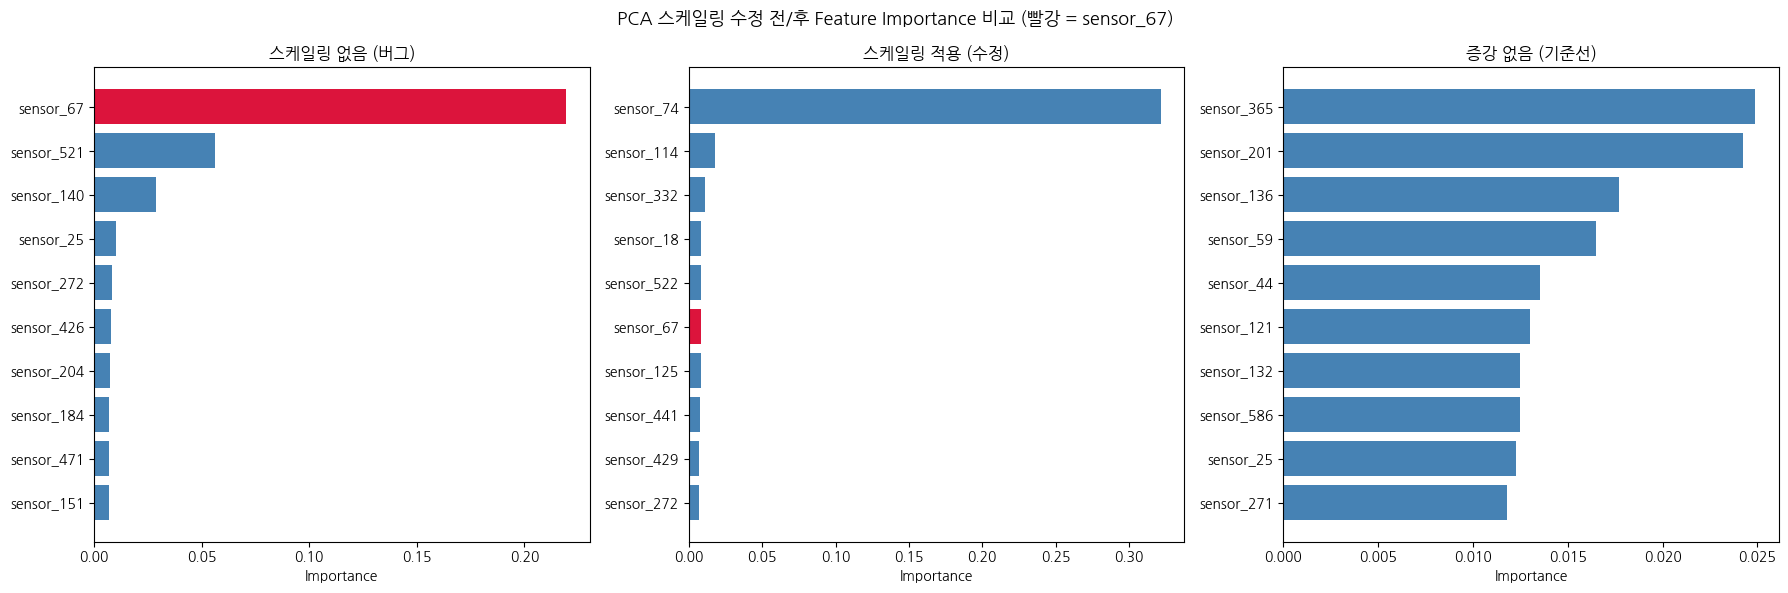

In [ ]:
# [Cell 14] 세 버전(스케일링 전/후/기준선) Feature Importance Top 10 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

versions = [
    ("스케일링 없음 (버그)", importance_no_scaling),
    ("스케일링 적용 (수정)", importance_scaled),
    ("증강 없음 (기준선)", importance_none),
]

for ax, (title, df) in zip(axes, versions):
    top10 = df.head(10)
    colors = ["crimson" if s == "sensor_67" else "steelblue" for s in top10["sensor"]]
    ax.barh(top10["sensor"][::-1], top10["importance"][::-1], color=colors[::-1])
    ax.set_title(title)
    ax.set_xlabel("Importance")

plt.suptitle("PCA 스케일링 수정 전/후 Feature Importance 비교 (빨강 = sensor_67)", fontsize=13)
plt.tight_layout()
plt.show()

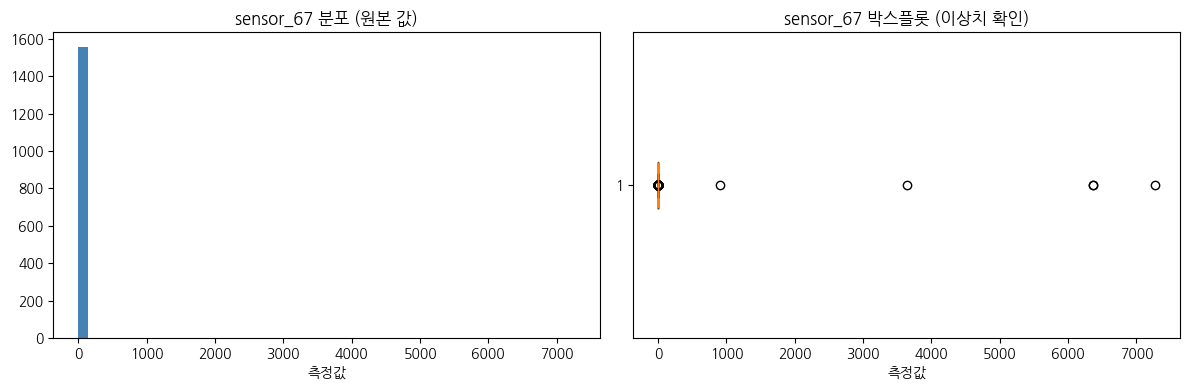

sensor_67 통계:
  - Skewness: 20.765 (0에서 멀수록 비대칭/치우침)
  - IQR 기준 이상치 비율: 7.75%
  - min=0.41, max=7272.83, median=0.98, std=307.50

⚠️ sensor_67은 치우침이 크거나 이상치가 많은 편 -> RobustScaler로도 완전히 정규화 안 될 수 있음


In [ ]:
# [Cell 15] sensor_67 원본 분포 확인 (이상치/skew 여부 점검)
import matplotlib.pyplot as plt

sensor_67_raw = X["sensor_67"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sensor_67_raw, bins=50, color="steelblue")
axes[0].set_title("sensor_67 분포 (원본 값)")
axes[0].set_xlabel("측정값")

axes[1].boxplot(sensor_67_raw, vert=False)
axes[1].set_title("sensor_67 박스플롯 (이상치 확인)")
axes[1].set_xlabel("측정값")

plt.tight_layout()
plt.show()

# 수치로도 확인: skewness, 이상치 비율
from scipy.stats import skew

skewness = skew(sensor_67_raw)
q1, q3 = sensor_67_raw.quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outlier_ratio = ((sensor_67_raw < lower_bound) | (sensor_67_raw > upper_bound)).mean()

print(f"sensor_67 통계:")
print(f"  - Skewness: {skewness:.3f} (0에서 멀수록 비대칭/치우침)")
print(f"  - IQR 기준 이상치 비율: {outlier_ratio*100:.2f}%")
print(f"  - min={sensor_67_raw.min():.2f}, max={sensor_67_raw.max():.2f}, "
      f"median={sensor_67_raw.median():.2f}, std={sensor_67_raw.std():.2f}")

if abs(skewness) > 1 or outlier_ratio > 0.05:
    print("\n⚠️ sensor_67은 치우침이 크거나 이상치가 많은 편 -> RobustScaler로도 완전히 정규화 안 될 수 있음")
else:
    print("\nℹ️ 분포 자체는 크게 이상하지 않음 -> 잔존 artifact는 다른 원인(예: GMM 컴포넌트 선택) 가능성")

In [ ]:
# [Cell 16] sensor_67 순위 반복 검증 (random_state를 바꿔가며 재확인)
def repeated_rank_check(X, y, sensor_name="sensor_67", n_repeats=10, base_seed=0):
    """
    스케일링 적용 버전에서 random_state를 여러 개 바꿔 돌려보고,
    sensor_67(또는 지정 센서)의 순위가 매번 비슷하게 나오는지(=패턴) 아니면
    들쭉날쭉한지(=우연/노이즈) 확인한다.
    """
    imputer_full = SimpleImputer(strategy="median")
    X_imp_full = imputer_full.fit_transform(X)

    ranks = []
    for seed in range(base_seed, base_seed + n_repeats):
        X_aug, y_aug, _ = gmm_pca_oversample(X_imp_full, y.values, random_state=seed)
        spw = (y_aug == 0).sum() / max((y_aug == 1).sum(), 1)
        pipeline = Pipeline([("scaler", RobustScaler()), ("model", get_model("xgboost", spw))])
        pipeline.fit(X_aug, y_aug)

        importance_df = pd.DataFrame({
            "sensor": X.columns,
            "importance": pipeline.named_steps["model"].feature_importances_
        }).sort_values("importance", ascending=False).reset_index(drop=True)

        rank = get_rank(importance_df, sensor_name)
        ranks.append(rank)
        print(f"[seed={seed}] {sensor_name} 순위: {rank}위")

    ranks_arr = np.array([r if r is not None else len(X.columns) for r in ranks])
    print(f"\n=== {n_repeats}회 반복 결과 ===")
    print(f"평균 순위: {ranks_arr.mean():.1f}위, 표준편차: {ranks_arr.std():.1f}")
    print(f"순위 범위: {ranks_arr.min()}위 ~ {ranks_arr.max()}위")

    if ranks_arr.mean() <= 20 and ranks_arr.std() < 15:
        print("\n⚠️ 결론: 여러 seed에서 일관되게 상위권 -> 우연이 아니라 구조적인 잔존 artifact로 판단. "
              f"-> {sensor_name}을 TRUSTED_SENSORS에서 제외 권장")
        verdict = "consistent_artifact"
    elif ranks_arr.std() > 30:
        print("\nℹ️ 결론: seed마다 순위가 크게 들쭉날쭉 -> 우연성이 강함, 특정 seed(42)에서만 튄 것일 수 있음")
        verdict = "noisy_not_consistent"
    else:
        print("\nℹ️ 결론: 애매한 패턴 -> 보수적으로 제외하는 것을 권장")
        verdict = "ambiguous"

    return ranks, verdict


ranks_sensor67, verdict_sensor67 = repeated_rank_check(X, y, sensor_name="sensor_67", n_repeats=10, base_seed=0)

[seed=0] sensor_67 순위: 3위
[seed=1] sensor_67 순위: 3위
[seed=2] sensor_67 순위: 10위
[seed=3] sensor_67 순위: 7위
[seed=4] sensor_67 순위: 3위
[seed=5] sensor_67 순위: 2위
[seed=6] sensor_67 순위: 4위
[seed=7] sensor_67 순위: 6위
[seed=8] sensor_67 순위: 8위
[seed=9] sensor_67 순위: 5위

=== 10회 반복 결과 ===
평균 순위: 5.1위, 표준편차: 2.5
순위 범위: 2위 ~ 10위

⚠️ 결론: 여러 seed에서 일관되게 상위권 -> 우연이 아니라 구조적인 잔존 artifact로 판단. -> sensor_67을 TRUSTED_SENSORS에서 제외 권장


In [ ]:
# [Cell 17] SHAP 설명 추출 함수
def get_shap_explanation(sample_idx_in_array, feature_names, shap_values, sample_values, top_n=5):
    shap_row = shap_values[sample_idx_in_array]
    top_idx = np.argsort(np.abs(shap_row))[::-1][:top_n]
    return [
        {"sensor": feature_names[i], "value": float(sample_values[sample_idx_in_array][i]),
         "shap_contribution": float(shap_row[i])}
        for i in top_idx
    ]

In [ ]:
# [Cell 18] EtchProcessAgent 클래스 정의
class EtchProcessAgent:
    """
    VM-FDC 가이던스 에이전트
    - Stage 1: 비용 민감형 동적 스크리닝 (Decision-Making)
    - Stage 2: Artifact 필터링 기반 원인 진단 (XAI Guidance)
    - Stage 3: 가상 피드백 제어 (Action Control, mocking)
    """
    def __init__(self, pipeline, imputer, selector, threshold: float, cost_ratio: float,
                 artifact_features: list, trusted_sensors: list, high_risk_proba: float = 0.7,
                 llm_client=None):
        self.pipeline = pipeline
        self.imputer = imputer
        self.selector = selector
        self.threshold = threshold
        self.cost_ratio = cost_ratio
        self.artifact_features = set(artifact_features)
        self.trusted_sensors = trusted_sensors
        self.high_risk_proba = high_risk_proba
        self.llm_client = llm_client

    def _predict_proba(self, wafer_fdc_data: np.ndarray) -> float:
        X_imp = self.imputer.transform(wafer_fdc_data)
        X_imp = apply_selector(X_imp, self.selector)  # [수정] 통일된 적용 함수
        return self.pipeline.predict_proba(X_imp)[0, 1]

    def monitor_wafer(self, wafer_fdc_data: np.ndarray, feature_names: list, wafer_id: str = "unknown") -> dict:
        fail_prob = self._predict_proba(wafer_fdc_data)

        if fail_prob >= self.threshold:
            print(f"[⚠️ 위험 감지] Wafer {wafer_id} 불량 확률: {fail_prob:.4f} "
                  f"(기준 {self.threshold:.4f}, Cost Ratio {self.cost_ratio}:1) -> 정밀 VM 대상 선별")
            shap_explanation = self._get_shap_explanation(wafer_fdc_data, feature_names)
            guidance = self._generate_guidance(fail_prob, shap_explanation, wafer_id)
            action = self._decide_action(fail_prob, guidance["top_sensor"])
            self._execute_action(action)
            return {"wafer_id": wafer_id, "fail_prob": fail_prob, "routing": "INSPECT",
                    "top_sensor": guidance["top_sensor"], "action_type": action["action_type"]}
        else:
            print(f"[✅ 정상 공정] Wafer {wafer_id} 불량 확률: {fail_prob:.4f} -> 다음 공정 Pass (검사 비용 절감)")
            return {"wafer_id": wafer_id, "fail_prob": fail_prob, "routing": "PASS",
                    "top_sensor": None, "action_type": "MONITOR_ONLY"}

    def _get_shap_explanation(self, wafer_fdc_data: np.ndarray, feature_names: list, top_n: int = 5) -> list:
        X_imp = self.imputer.transform(wafer_fdc_data)
        X_imp = apply_selector(X_imp, self.selector)  # [수정]
        X_scaled = self.pipeline.named_steps["scaler"].transform(X_imp)

        explainer = shap.TreeExplainer(self.pipeline.named_steps["model"])
        shap_row = explainer.shap_values(X_scaled)[0]
        top_idx = np.argsort(np.abs(shap_row))[::-1][:top_n]

        return [
            {"sensor": feature_names[i], "value": float(X_imp[0][i]), "shap_contribution": float(shap_row[i])}
            for i in top_idx
        ]

    def _filter_trusted(self, shap_explanation: list) -> list:
        filtered = [
            item for item in shap_explanation
            if item["sensor"] not in self.artifact_features and item["sensor"] in self.trusted_sensors
        ]
        if not filtered:
            filtered = [item for item in shap_explanation if item["sensor"] not in self.artifact_features]
        return filtered[:3]

    def _get_top_risk_increasing_sensor(self, trusted: list) -> tuple:
        risk_increasing = [item for item in trusted if item["shap_contribution"] > 0]
        if risk_increasing:
            top = max(risk_increasing, key=lambda x: x["shap_contribution"])
            return top["sensor"], True
        if trusted:
            return trusted[0]["sensor"], False
        return "unknown", False

    def _generate_guidance(self, fail_prob: float, shap_explanation: list, wafer_id: str) -> dict:
        excluded = [item["sensor"] for item in shap_explanation if item["sensor"] in self.artifact_features]
        trusted = self._filter_trusted(shap_explanation)
        top_sensor, is_risk_increasing = self._get_top_risk_increasing_sensor(trusted)

        print(f"[🤖 Agent 가이던스 리포트] Wafer {wafer_id}")
        if excluded:
            print(f" - 제외된 Artifact 센서: {', '.join(excluded)} (GMM+PCA 증강 산물로 판정)")
        print(f" - 주요 유발 인자(위험 증가 기준): {top_sensor}"
              f"{'' if is_risk_increasing else ' (※ 위험 증가 센서 없어 영향력 1위로 대체)'}")
        print(f" - 추천 액션: {top_sensor} 관련 Recipe 파라미터 및 Chamber 상태 점검")

        if self.llm_client is not None:
            report_text = self._generate_llm_report(fail_prob, trusted, excluded, wafer_id, top_sensor, is_risk_increasing)
            print(f"\n[LLM 상세 리포트]\n{report_text}")

        return {"top_sensor": top_sensor}

    def _generate_llm_report(self, fail_prob: float, trusted_shap: list, excluded: list,
                               wafer_id: str, top_sensor: str, is_risk_increasing: bool) -> str:
        context = f"샘플 ID: {wafer_id}\n불량 확률: {fail_prob:.1%} (기준 {self.threshold:.4f})\n\n"
        if excluded:
            context += f"[필터링됨] 증강 Artifact로 판명되어 제외된 센서: {', '.join(excluded)}\n\n"
        context += "신뢰 검증된 주요 인자 (SHAP 기여도 순):\n"
        for item in trusted_shap:
            direction = "위험 증가" if item["shap_contribution"] > 0 else "위험 감소"
            context += f"- {item['sensor']}: 측정값 {item['value']:.2f}, {direction} (기여도 {item['shap_contribution']:.3f})\n"

        context += f"\n점검 대상으로 지정된 센서: {top_sensor}"
        if is_risk_increasing:
            context += " (위험 증가 방향 기여 센서 중 우선순위 1위)"
        else:
            context += " (이번 샘플에는 위험 증가 방향 센서가 없어, 영향력이 가장 큰 센서를 대신 지정함 — 해석에 주의 필요)"

        prompt = f"""당신은 반도체 Etch 공정 엔지니어를 보조하는 진단 어시스턴트입니다.
아래 정보는 머신러닝 모델 분석 결과이며, 신뢰할 수 없는 증강 artifact 센서는 이미 제외되었습니다.
점검 대상 센서가 '위험 증가 방향'으로 선정된 것인지, 아니면 '위험 증가 센서가 없어 대체된 것'인지
context에 명시되어 있으니 이를 정확히 반영해서 설명하세요. 점검 대상 센서가 위험을 감소시키는
방향이라면, 그 사실을 숨기지 말고 솔직하게 언급하세요. 제공된 정보 외의 내용을 추정하거나 단정하지 마세요.

{context}

형식:
1. 종합 판단 (1줄)
2. 핵심 원인 추정 센서 및 해석 (2~3줄, 점검 대상 센서가 위험 증가/감소 중 어느 방향인지 명확히 언급)
3. 권고 조치 (1~2줄)
"""
        response = self.llm_client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.2,
        )
        return response.choices[0].message.content

    def _decide_action(self, fail_prob: float, top_sensor: str) -> dict:
        if fail_prob >= self.high_risk_proba:
            return {
                "action_type": "INTERLOCK",
                "signal": "EQUIPMENT_PAUSE_REQUEST",
                "message": f"불량 확률 {fail_prob:.1%} - 고위험. 장비 일시 정지 시그널 발신(모킹). "
                           f"엔지니어 확인 전까지 후속 웨이퍼 투입 보류 권장.",
            }
        elif fail_prob >= self.threshold:
            return {
                "action_type": "RECIPE_ADJUSTMENT_SUGGESTION",
                "signal": "RECIPE_REVIEW_REQUEST",
                "message": f"불량 확률 {fail_prob:.1%} - 중위험. {top_sensor} 관련 Recipe 파라미터 점검 권장 "
                           f"(예: 해당 공정 Step의 가스 유량/RF Power ±5% 조정 검토).",
            }
        return {"action_type": "MONITOR_ONLY", "signal": "NONE", "message": "정상 범위 - 추가 조치 불필요."}

    def _execute_action(self, action: dict) -> None:
        print(f"[🔧 Interlock/Recipe 시스템 모킹] action_type={action['action_type']}, signal={action['signal']}")
        print(f"  -> {action['message']}")

In [ ]:
# ============================================================
# [Cell 19] Held-out Outer Test 평가 + Agent 데모
# (Leakage-free 자동 선정 Operating Point 기반)
# ============================================================

# fold_artifacts의 첫 번째 Outer Fold를 데모에 사용
DEMO_ARTIFACT_INDEX = 0

# Agent 정성 데모 샘플 수
N_FAIL_DEMO = 3
N_PASS_DEMO = 3

# 실제 LLM 호출 여부
# False: API 호출 없이 Agent 로직만 확인
# True : GPT 리포트까지 생성
USE_LLM_DEMO = False

RANDOM_STATE = 42


# ------------------------------------------------------------
# 1. 데모 Outer Fold 불러오기
# ------------------------------------------------------------
if not (
    0 <= DEMO_ARTIFACT_INDEX
    < len(fold_artifacts)
):
    raise IndexError(
        "DEMO_ARTIFACT_INDEX가 "
        "fold_artifacts 범위를 벗어났습니다."
    )

demo_fold = fold_artifacts[
    DEMO_ARTIFACT_INDEX
]

outer_id = int(
    demo_fold["fold"]
)

repeat_id = int(
    demo_fold["repeat"]
)

fold_in_repeat = int(
    demo_fold["fold_in_repeat"]
)

pipeline_demo = demo_fold["pipeline"]
imputer_demo = demo_fold["imputer"]
selector_demo = demo_fold["selector"]

train_idx = demo_fold["train_idx"]
test_idx = demo_fold["test_idx"]


# ------------------------------------------------------------
# 2. Inner OOF에서 이미 선정된 값 사용
#    여기서 Cost Ratio나 Threshold를 다시 탐색하지 않음
# ------------------------------------------------------------
selected_cost_ratio_demo = int(
    demo_fold["selected_cost_ratio"]
)

optimal_threshold_demo = float(
    demo_fold["best_threshold"]
)

print("=" * 70)
print("데모 Fold Operating Point")
print("=" * 70)

print(
    f"Outer Fold         : "
    f"{outer_id}/25 "
    f"(Repeat {repeat_id}, "
    f"Fold {fold_in_repeat})"
)

print(
    f"Selected Cost Ratio: "
    f"{selected_cost_ratio_demo}:1"
)

print(
    f"Selected Threshold : "
    f"{optimal_threshold_demo:.5f}"
)

print(
    "선정 데이터        : "
    "Outer Train의 Strict Inner OOF"
)


# ------------------------------------------------------------
# 3. vm_results와 Artifact 값 일치 여부 검증
# ------------------------------------------------------------
vm_result_demo = (
    vm_results.loc[
        vm_results["fold"] == outer_id
    ]
    .iloc[0]
)

stored_ratio = int(
    vm_result_demo["selected_cost_ratio"]
)

stored_threshold = float(
    vm_result_demo["best_threshold"]
)

ratio_match = (
    stored_ratio
    == selected_cost_ratio_demo
)

threshold_match = np.isclose(
    stored_threshold,
    optimal_threshold_demo,
    atol=1e-12
)

print("\n=== Artifact 일치 검증 ===")

print(
    f"Cost Ratio  : "
    f"{'✅ 일치' if ratio_match else '⚠️ 불일치'}"
)

print(
    f"Threshold   : "
    f"{'✅ 일치' if threshold_match else '⚠️ 불일치'}"
)

if not ratio_match or not threshold_match:
    raise ValueError(
        "vm_results와 fold_artifacts의 "
        "Operating Point가 일치하지 않습니다."
    )


# ------------------------------------------------------------
# 4. 선택 Feature 이름 복원
# ------------------------------------------------------------
if selector_demo is None:
    selected_feature_names = (
        X.columns.tolist()
    )

else:
    non_constant_mask = (
        selector_demo["mask"]
    )

    selected_indices = (
        selector_demo["selector"]
        .get_support(indices=True)
    )

    non_constant_feature_names = (
        np.asarray(X.columns)[
            non_constant_mask
        ]
    )

    selected_feature_names = (
        non_constant_feature_names[
            selected_indices
        ]
        .tolist()
    )

print(
    f"\n선택 Feature 수    : "
    f"{len(selected_feature_names)}개"
)


# ------------------------------------------------------------
# 5. Held-out Outer Test 전체 성능 재확인
# ------------------------------------------------------------
X_test_raw = X.values[test_idx]
y_test = y.values[test_idx]

X_test_imp = imputer_demo.transform(
    X_test_raw
)

X_test_selected = apply_selector(
    X_test_imp,
    selector_demo
)

test_proba = (
    pipeline_demo
    .predict_proba(X_test_selected)[:, 1]
)

test_pred = (
    test_proba
    >= optimal_threshold_demo
).astype(int)

heldout_recall = recall_score(
    y_test,
    test_pred,
    zero_division=0
)

heldout_precision = precision_score(
    y_test,
    test_pred,
    zero_division=0
)

heldout_auc = roc_auc_score(
    y_test,
    test_proba
)

heldout_inspection_reduction = (
    1 - test_pred.mean()
) * 100

print("\n" + "=" * 70)
print("Held-out Outer Test 성능")
print("=" * 70)

print(
    f"Recall              : "
    f"{heldout_recall:.3f}"
)

print(
    f"Precision           : "
    f"{heldout_precision:.3f}"
)

print(
    f"AUC                 : "
    f"{heldout_auc:.3f}"
)

print(
    f"검사 대상 감소      : "
    f"{heldout_inspection_reduction:.1f}%"
)

print(
    f"검사 대상 수        : "
    f"{test_pred.sum()}/{len(test_pred)}건"
)


# ------------------------------------------------------------
# 6. Agent 생성
# ------------------------------------------------------------
llm_for_demo = (
    client if USE_LLM_DEMO else None
)

agent = EtchProcessAgent(
    pipeline=pipeline_demo,
    imputer=imputer_demo,
    selector=selector_demo,
    threshold=optimal_threshold_demo,
    cost_ratio=selected_cost_ratio_demo,

    # SMOTE 모델이므로 우선 빈 리스트 사용
    # 별도로 검증한 Artifact 센서가 있으면 입력
    artifact_features=[],

    trusted_sensors=selected_feature_names,
    high_risk_proba=0.7,
    llm_client=llm_for_demo
)


# ------------------------------------------------------------
# 7. Agent 정성 데모 샘플 선정
# ------------------------------------------------------------
fail_positions = np.where(
    y_test == 1
)[0]

pass_positions = np.where(
    y_test == 0
)[0]

rng = np.random.RandomState(
    RANDOM_STATE
)

n_fail_demo = min(
    N_FAIL_DEMO,
    len(fail_positions)
)

n_pass_demo = min(
    N_PASS_DEMO,
    len(pass_positions)
)

if n_fail_demo > 0:
    fail_demo_positions = rng.choice(
        fail_positions,
        size=n_fail_demo,
        replace=False
    )
else:
    fail_demo_positions = np.array(
        [],
        dtype=int
    )

if n_pass_demo > 0:
    pass_demo_positions = rng.choice(
        pass_positions,
        size=n_pass_demo,
        replace=False
    )
else:
    pass_demo_positions = np.array(
        [],
        dtype=int
    )

demo_positions = np.concatenate([
    fail_demo_positions,
    pass_demo_positions
])


# ------------------------------------------------------------
# 8. Agent 데모 실행
# ------------------------------------------------------------
results_log = []

print("\n" + "=" * 70)
print("Agent Held-out Sample Demo")
print("=" * 70)

for position in demo_positions:
    original_row_idx = test_idx[position]

    wafer_id = str(
        X.index[original_row_idx]
    )

    true_label = int(
        y_test[position]
    )

    wafer_data = X.values[
        original_row_idx:
        original_row_idx + 1
    ]

    result = agent.monitor_wafer(
        wafer_fdc_data=wafer_data,
        feature_names=selected_feature_names,
        wafer_id=wafer_id
    )

    result["true_label"] = (
        "Fail" if true_label == 1
        else "Pass"
    )

    result["correct_routing"] = (
        (
            true_label == 1
            and result["routing"] == "INSPECT"
        )
        or
        (
            true_label == 0
            and result["routing"] == "PASS"
        )
    )

    results_log.append(result)

    print(
        f" - 실제 Label : "
        f"{result['true_label']}"
    )

    print(
        f" - Agent 판단 : "
        f"{result['routing']}"
    )

    print(
        f" - 판단 일치  : "
        f"{'✅' if result['correct_routing'] else '⚠️'}"
    )

    print("-" * 50)


# ------------------------------------------------------------
# 9. 데모 결과 요약
# ------------------------------------------------------------
results_log_df = pd.DataFrame(
    results_log
)

if not results_log_df.empty:
    print("\n=== Agent 데모 결과 ===")

    display_columns = [
        "wafer_id",
        "true_label",
        "fail_prob",
        "routing",
        "top_sensor",
        "action_type",
        "correct_routing"
    ]

    display(
        results_log_df[
            display_columns
        ]
    )

    fail_demo_df = results_log_df[
        results_log_df["true_label"]
        == "Fail"
    ]

    pass_demo_df = results_log_df[
        results_log_df["true_label"]
        == "Pass"
    ]

    if not fail_demo_df.empty:
        detected_fail_count = (
            fail_demo_df["routing"]
            .eq("INSPECT")
            .sum()
        )

        print(
            f"불량 데모 감지: "
            f"{detected_fail_count}/"
            f"{len(fail_demo_df)}건"
        )

    if not pass_demo_df.empty:
        false_positive_count = (
            pass_demo_df["routing"]
            .eq("INSPECT")
            .sum()
        )

        print(
            f"정상 데모 추가검사: "
            f"{false_positive_count}/"
            f"{len(pass_demo_df)}건"
        )

else:
    print(
        "데모에 사용할 샘플이 없습니다."
    )

데모 Fold Operating Point
Outer Fold         : 1/25 (Repeat 1, Fold 1)
Selected Cost Ratio: 15:1
Selected Threshold : 0.00847
선정 데이터        : Outer Train의 Strict Inner OOF

=== Artifact 일치 검증 ===
Cost Ratio  : ✅ 일치
Threshold   : ✅ 일치

선택 Feature 수    : 100개

Held-out Outer Test 성능
Recall              : 0.524
Precision           : 0.080
AUC                 : 0.672
검사 대상 감소      : 56.4%
검사 대상 수        : 137/314건

Agent Held-out Sample Demo
[✅ 정상 공정] Wafer 2008-07-29 08:23:00 불량 확률: 0.0028 -> 다음 공정 Pass (검사 비용 절감)
 - 실제 Label : Fail
 - Agent 판단 : PASS
 - 판단 일치  : ⚠️
--------------------------------------------------
[✅ 정상 공정] Wafer 2008-05-10 15:35:00 불량 확률: 0.0062 -> 다음 공정 Pass (검사 비용 절감)
 - 실제 Label : Fail
 - Agent 판단 : PASS
 - 판단 일치  : ⚠️
--------------------------------------------------
[⚠️ 위험 감지] Wafer 2008-02-10 21:32:00 불량 확률: 0.0493 (기준 0.0085, Cost Ratio 15:1) -> 정밀 VM 대상 선별
[🤖 Agent 가이던스 리포트] Wafer 2008-02-10 21:32:00
 - 주요 유발 인자(위험 증가 기준): sensor_348
 - 추천 액션: sensor_348 관련 Reci

,wafer_id,true_label,fail_prob,routing,top_sensor,action_type,correct_routing
0,2008-07-29 08:23:00,Fail,0.002781,PASS,None,MONITOR_ONLY,False
1,2008-05-10 15:35:00,Fail,0.006234,PASS,None,MONITOR_ONLY,False
2,2008-02-10 21:32:00,Fail,0.049303,INSPECT,sensor_348,RECIPE_ADJUSTMENT_SUGGESTION,True
3,2008-10-15 19:15:00,Pass,0.000902,PASS,None,MONITOR_ONLY,True
4,2008-07-29 23:14:00,Pass,0.241100,INSPECT,sensor_247,RECIPE_ADJUSTMENT_SUGGESTION,False
5,2008-08-21 13:45:00,Pass,0.000447,PASS,None,MONITOR_ONLY,True


불량 데모 감지: 1/3건
정상 데모 추가검사: 1/3건
